# Task 2: Multi-Modal Cardiac Image Fusion

**Scenario:** Senior perception engineer at a cardiac research institute.
CT scans show excellent structural boundaries; MRI scans are superior at showing soft tissue.
We mathematically fuse aligned CT and MRI slices of the same heart into a single unified matrix.


In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import os

os.makedirs('output', exist_ok=True)

## Step 1: Load Both Modalities

We need a matched pair -- CT slice and MRI slice of the same heart cross-section.
Both must be resized to the same dimensions before any matrix operations.

CT  shape: (256, 256),  range: [0, 174]
MRI shape: (256, 256), range: [0, 144]


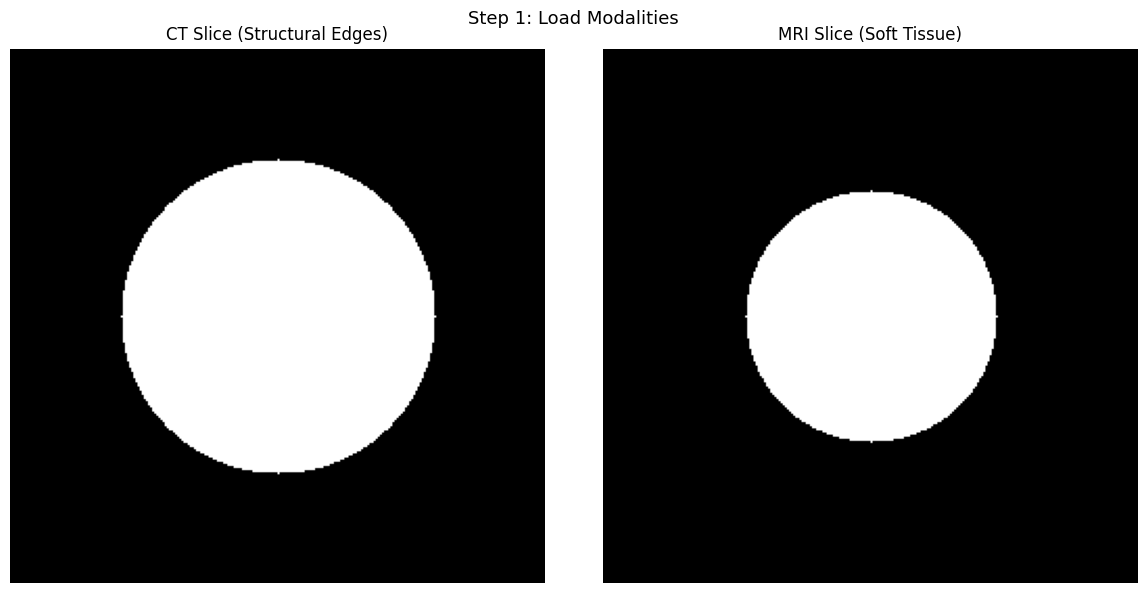

Saved -> output/01_raw_modalities.png


In [2]:
# load the CT slice as grayscale (structural info -- bones, walls)
img_ct = cv2.imread('data/sample_ct.png', cv2.IMREAD_GRAYSCALE)

# load the MRI slice as grayscale (soft tissue info)
img_mri = cv2.imread('data/sample_mri.png', cv2.IMREAD_GRAYSCALE)

if img_ct is None or img_mri is None:
    raise FileNotFoundError(
        "Place matched CT/MRI images at data/sample_ct.png and data/sample_mri.png"
    )

# resize MRI to match CT dimensions if they differ
if img_ct.shape != img_mri.shape:
    img_mri = cv2.resize(img_mri, (img_ct.shape[1], img_ct.shape[0]))
    print(f'MRI resized to {img_ct.shape}')

print(f'CT  shape: {img_ct.shape},  range: [{img_ct.min()}, {img_ct.max()}]')
print(f'MRI shape: {img_mri.shape}, range: [{img_mri.min()}, {img_mri.max()}]')

fig, axes = plt.subplots(1, 2, figsize=(12,6))
axes[0].imshow(img_ct, cmap='gray')
axes[0].set_title('CT Slice (Structural Edges)')
axes[0].axis('off')
axes[1].imshow(img_mri, cmap='gray')
axes[1].set_title('MRI Slice (Soft Tissue)')
axes[1].axis('off')
plt.suptitle('Step 1: Load Modalities', fontsize=13)
plt.tight_layout()
plt.savefig('output/01_raw_modalities.png', dpi=150)
plt.show()
print('Saved -> output/01_raw_modalities.png')

## Step 2: Histogram Equalization on Both Modalities

Before blending, each modality needs its full dynamic range utilized.
Equalize CT and MRI independently so neither dominates the fusion due to
a narrower intensity spread.

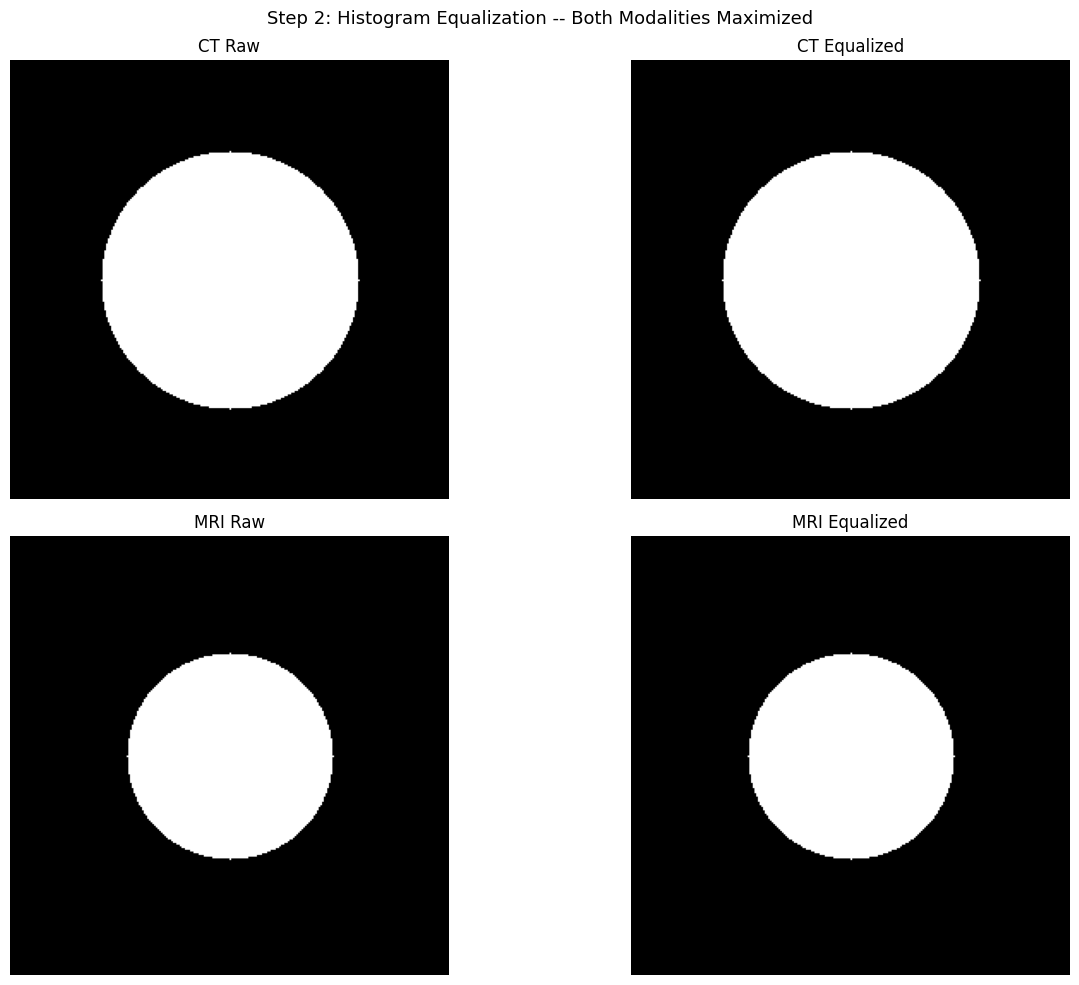

Saved -> output/02_equalized_modalities.png


In [3]:
# equalize each modality independently -- maximizes each one's dynamic range
ct_eq  = cv2.equalizeHist(img_ct)
mri_eq = cv2.equalizeHist(img_mri)

fig, axes = plt.subplots(2, 2, figsize=(14,10))
axes[0,0].imshow(img_ct,  cmap='gray'); axes[0,0].set_title('CT Raw');       axes[0,0].axis('off')
axes[0,1].imshow(ct_eq,   cmap='gray'); axes[0,1].set_title('CT Equalized'); axes[0,1].axis('off')
axes[1,0].imshow(img_mri, cmap='gray'); axes[1,0].set_title('MRI Raw');      axes[1,0].axis('off')
axes[1,1].imshow(mri_eq,  cmap='gray'); axes[1,1].set_title('MRI Equalized');axes[1,1].axis('off')
plt.suptitle('Step 2: Histogram Equalization -- Both Modalities Maximized', fontsize=13)
plt.tight_layout()
plt.savefig('output/02_equalized_modalities.png', dpi=150)
plt.show()
print('Saved -> output/02_equalized_modalities.png')

## Step 3: Color Mapping and Fusion

Convert each modality to a colored heatmap to visually distinguish them, then
overlay the matrices. The MRI gets a warm colormap (COLORMAP_HOT) and the CT gets
a cool one (COLORMAP_BONE) so both contribute distinct visible information.

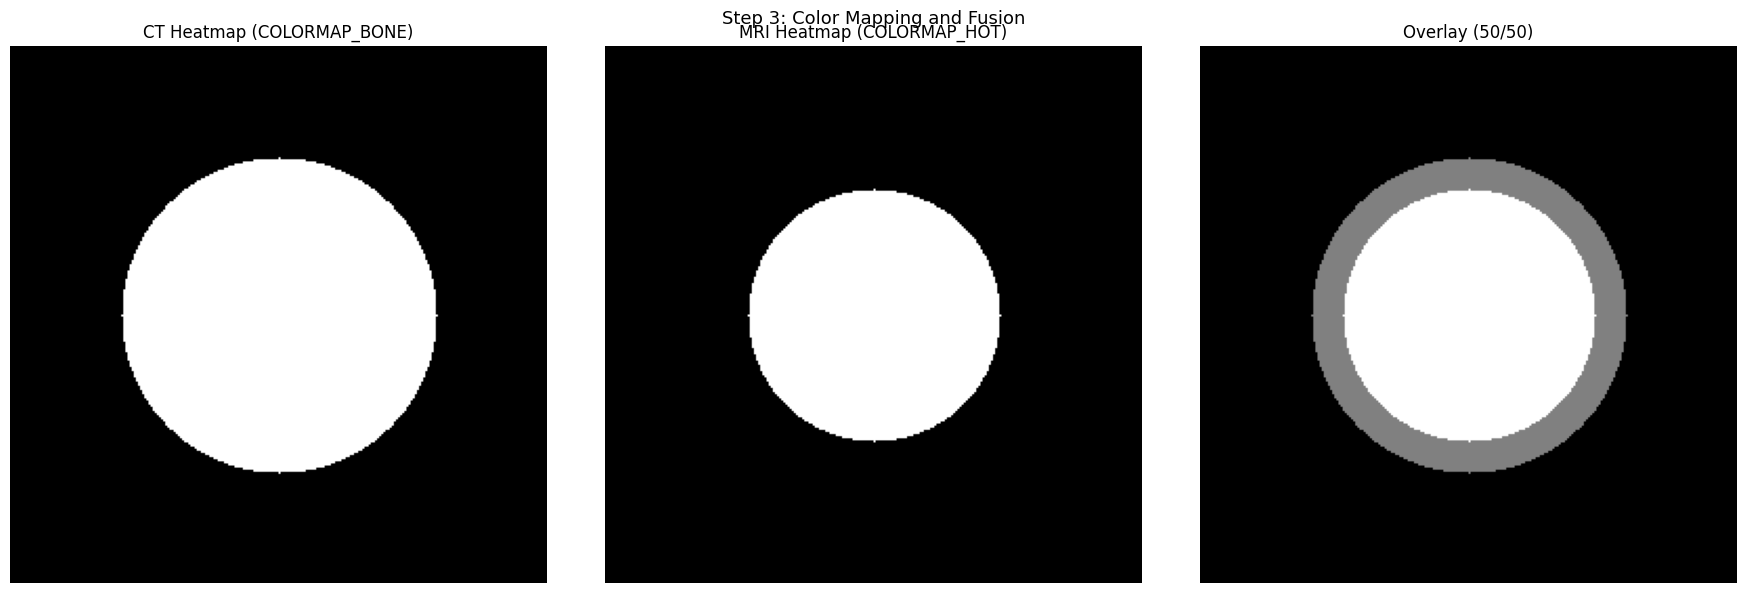

Saved -> output/03_color_mapping_fusion.png


In [4]:
# map each modality to a distinct colormap
ct_colored  = cv2.applyColorMap(ct_eq, cv2.COLORMAP_BONE)  # cool/gray -- structural
mri_colored = cv2.applyColorMap(mri_eq, cv2.COLORMAP_HOT)  # warm -- tissue variations

# simple 50/50 overlay to create a unified view
img_overlay = cv2.addWeighted(ct_colored, 0.5, mri_colored, 0.5, 0)

fig, axes = plt.subplots(1, 3, figsize=(18,6))
axes[0].imshow(cv2.cvtColor(ct_colored, cv2.COLOR_BGR2RGB))
axes[0].set_title('CT Heatmap (COLORMAP_BONE)')
axes[0].axis('off')
axes[1].imshow(cv2.cvtColor(mri_colored, cv2.COLOR_BGR2RGB))
axes[1].set_title('MRI Heatmap (COLORMAP_HOT)')
axes[1].axis('off')
axes[2].imshow(cv2.cvtColor(img_overlay, cv2.COLOR_BGR2RGB))
axes[2].set_title('Overlay (50/50)')
axes[2].axis('off')
plt.suptitle('Step 3: Color Mapping and Fusion', fontsize=13)
plt.tight_layout()
plt.savefig('output/03_color_mapping_fusion.png', dpi=150)
plt.show()
print('Saved -> output/03_color_mapping_fusion.png')

## Step 4: Multi-Modal Weighted Fusion (cv2.addWeighted)

The CT carries the gold standard anatomical edges so it gets a heavier weight (alpha).
The MRI highlights internal soft tissue so it gets a lighter weight (beta).
We experiment with a few alpha/beta pairs to find the best balance.

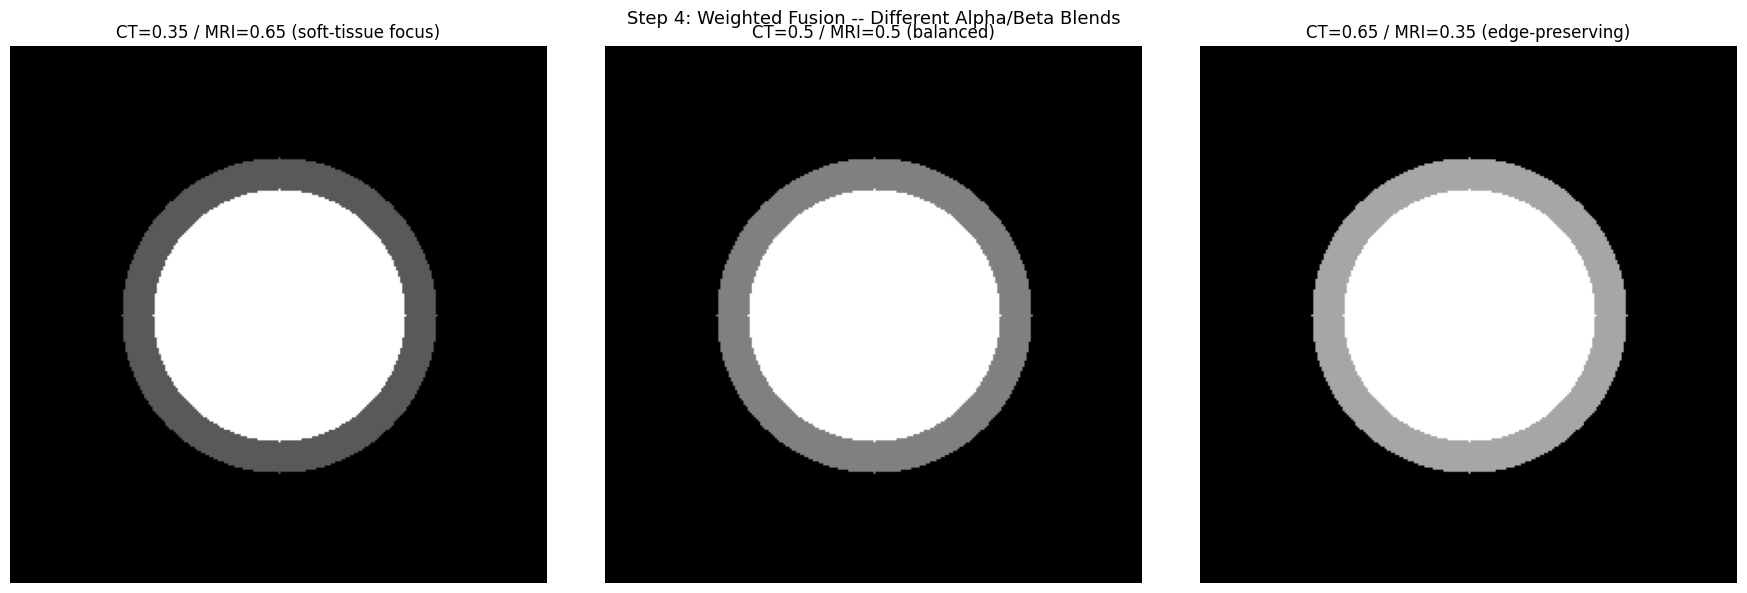

Saved -> output/04_weighted_fusion.png


In [5]:
# heavier CT weight preserves sharp anatomical edges; lighter MRI weight shows soft tissue
ALPHA = 0.65  # CT weight
BETA  = 0.35  # MRI weight

fused_main = cv2.addWeighted(ct_colored, ALPHA, mri_colored, BETA, 0)

# try a couple other blends for comparison
fused_equal = cv2.addWeighted(ct_colored, 0.5,  mri_colored, 0.5,  0)
fused_mri   = cv2.addWeighted(ct_colored, 0.35, mri_colored, 0.65, 0)  # MRI-dominant

fig, axes = plt.subplots(1, 3, figsize=(18,6))
axes[0].imshow(cv2.cvtColor(fused_mri,   cv2.COLOR_BGR2RGB))
axes[0].set_title(f'CT=0.35 / MRI=0.65 (soft-tissue focus)')
axes[0].axis('off')
axes[1].imshow(cv2.cvtColor(fused_equal, cv2.COLOR_BGR2RGB))
axes[1].set_title('CT=0.5 / MRI=0.5 (balanced)')
axes[1].axis('off')
axes[2].imshow(cv2.cvtColor(fused_main,  cv2.COLOR_BGR2RGB))
axes[2].set_title(f'CT={ALPHA} / MRI={BETA} (edge-preserving)')
axes[2].axis('off')
plt.suptitle('Step 4: Weighted Fusion -- Different Alpha/Beta Blends', fontsize=13)
plt.tight_layout()
plt.savefig('output/04_weighted_fusion.png', dpi=150)
plt.show()
print('Saved -> output/04_weighted_fusion.png')

## Step 5: Log and Power-Law Transforms on the Fused Image

AddWeighted can push some pixels to pure black or pure white (crushed / blown out).
We pass the fused result through both transforms to recover any lost detail at the extremes.

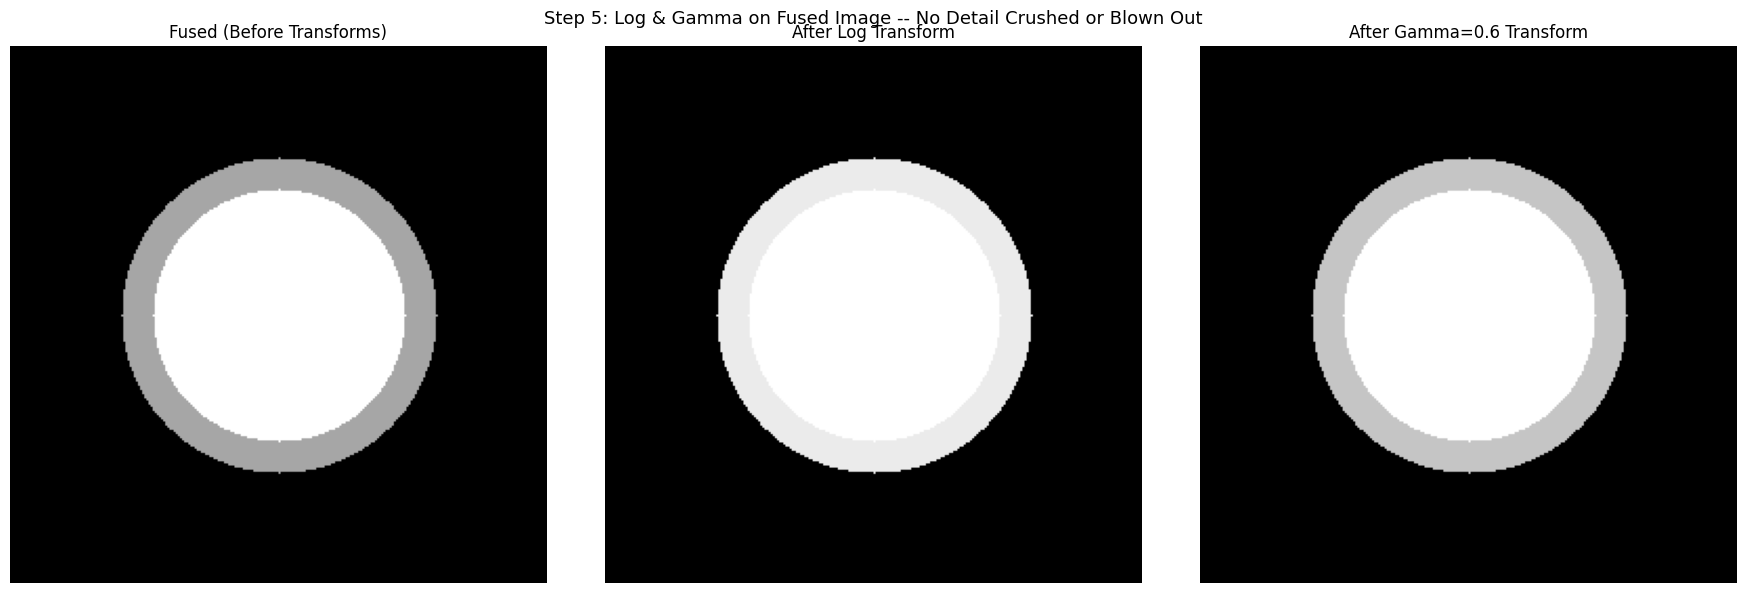

Saved -> output/05_log_gamma_on_fusion.png


In [6]:
# convert to float for math operations
fused_float = fused_main.astype(np.float32)

# --- logarithmic transform --- recover dark detail in the fused image
c_log = 255.0 / np.log1p(255.0)
fused_log = np.clip(c_log * np.log1p(fused_float), 0, 255).astype(np.uint8)

# --- power-law (gamma) transform --- recover bright detail
GAMMA = 0.6
fused_gamma = np.clip(np.power(fused_float / 255.0, GAMMA) * 255.0, 0, 255).astype(np.uint8)

fig, axes = plt.subplots(1, 3, figsize=(18,6))
axes[0].imshow(cv2.cvtColor(fused_main,  cv2.COLOR_BGR2RGB))
axes[0].set_title('Fused (Before Transforms)')
axes[0].axis('off')
axes[1].imshow(cv2.cvtColor(fused_log,   cv2.COLOR_BGR2RGB))
axes[1].set_title('After Log Transform')
axes[1].axis('off')
axes[2].imshow(cv2.cvtColor(fused_gamma, cv2.COLOR_BGR2RGB))
axes[2].set_title(f'After Gamma={GAMMA} Transform')
axes[2].axis('off')
plt.suptitle('Step 5: Log & Gamma on Fused Image -- No Detail Crushed or Blown Out', fontsize=13)
plt.tight_layout()
plt.savefig('output/05_log_gamma_on_fusion.png', dpi=150)
plt.show()
print('Saved -> output/05_log_gamma_on_fusion.png')

## Step 6: Comparative Analysis

Standalone CT vs. standalone MRI vs. our best fused output side-by-side.
This is the money shot -- shows exactly what the fusion adds over each individual modality.

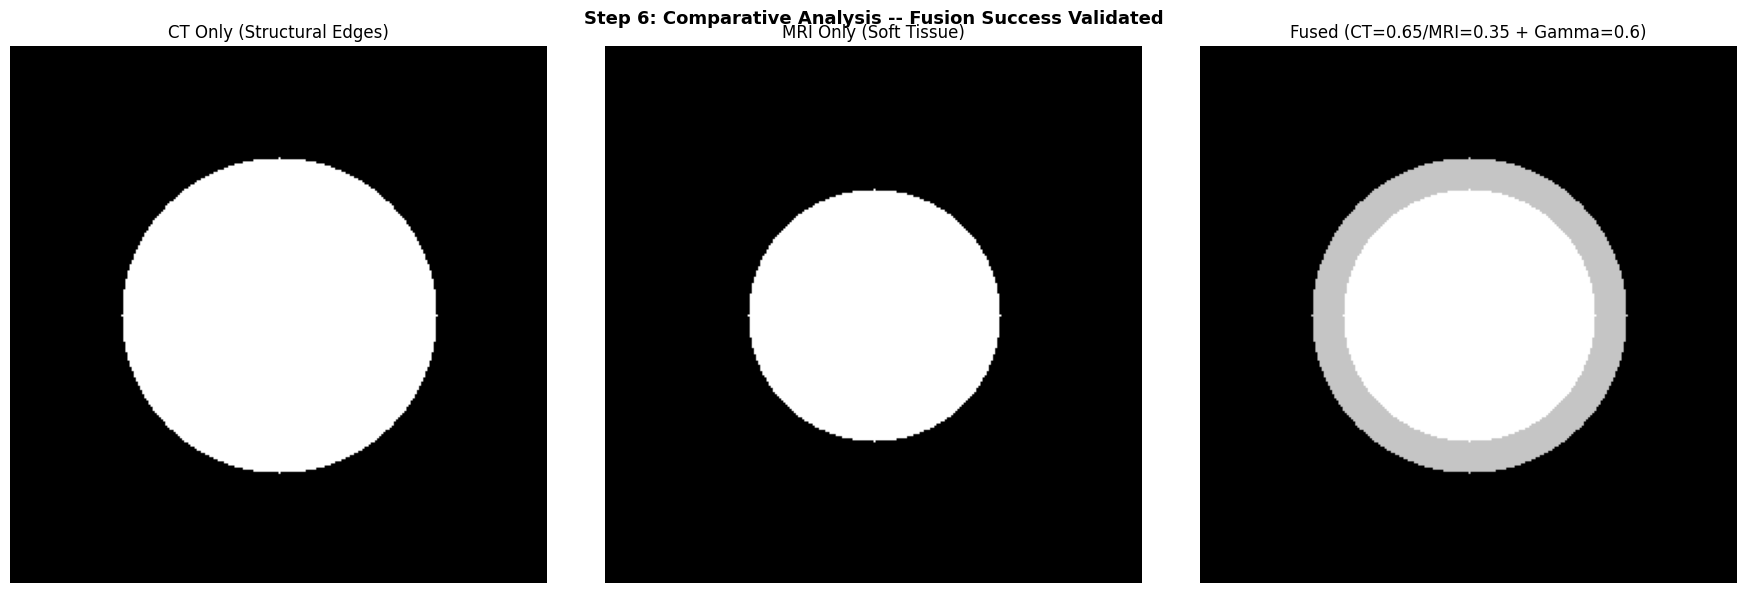

Saved -> output/06_comparative_analysis.png
All done!


In [7]:
fig, axes = plt.subplots(1, 3, figsize=(18,6))

axes[0].imshow(img_ct, cmap='gray')
axes[0].set_title('CT Only (Structural Edges)')
axes[0].axis('off')

axes[1].imshow(img_mri, cmap='gray')
axes[1].set_title('MRI Only (Soft Tissue)')
axes[1].axis('off')

# our best fused result
axes[2].imshow(cv2.cvtColor(fused_gamma, cv2.COLOR_BGR2RGB))
axes[2].set_title(f'Fused (CT={ALPHA}/MRI={BETA} + Gamma={GAMMA})')
axes[2].axis('off')

plt.suptitle('Step 6: Comparative Analysis -- Fusion Success Validated', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('output/06_comparative_analysis.png', dpi=150)
plt.show()
print('Saved -> output/06_comparative_analysis.png')
print('All done!')